In [26]:
import darts
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [12]:
import polars as pl

# 1. Scan
lf = pl.scan_csv("data.csv")

# 2. Transformation
processed_lf = (
    lf.with_columns([
        # Use str.slice to handle the " UTC" suffix efficiently
        pl.col("timedate")
          .str.slice(0, 19) 
          .str.to_datetime("%Y-%m-%d %H:%M:%S")
          .dt.truncate("1h")
          .alias("hour")
    ])
    .group_by(["deviceId", "period", "hour"])
    .agg([
        # Calculate mean for temperature columns t1 through t13
        # This regex ensures we only pick columns that are 't' followed by digits
        pl.col("^t\d+$").mean(), 
        
        # Other metrics
        pl.col("x1").mean(),
        pl.col("x2").mean(),
        pl.col("t1").min().alias("t1_min"),
        pl.col("t1").max().alias("t1_max"),
        pl.col("x3").first(),
        pl.col("deviceType").first()
    ])
    .sort(["deviceId", "hour"])
)

# 3. Single-pass execution
print("Starting aggregation (streaming 10GB)...")
final_df = processed_lf.collect(streaming=True)

print("Splitting and saving files...")
for p in ["train", "test", "valid"]:
    subset = final_df.filter(pl.col("period") == p)
    if not subset.is_empty():
        subset.write_csv(f"{p}_hourly.csv")
        print(f"✅ Saved {p}_hourly.csv ({len(subset)} rows)")

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_23663/2720612027.py:20: SyntaxWarning: invalid escape sequence '\d'
  pl.col("^t\d+$").mean(),
/tmp/ipykernel_23663/2720612027.py:35: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  final_df = processed_lf.collect(streaming=True)


Starting aggregation (streaming 10GB)...
Splitting and saving files...
✅ Saved train_hourly.csv (2905879 rows)
✅ Saved test_hourly.csv (1660460 rows)
✅ Saved valid_hourly.csv (841834 rows)


In [27]:
devices = pd.read_csv('devices.csv')
devices

,latitude,longitude,deviceId
0,50.0,18.3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
1,53.5,21.1,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...
2,52.9,18.1,01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2...
3,52.5,17.7,01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfc...
4,50.7,16.7,02e4ad5d8d0016d35a003ea6df7e10fe27093aba81c64a...
...,...,...,...
595,52.4,14.6,fbdf266dd372334fcd865972f980574608f7fc122ecf6c...
596,54.6,18.1,fc376d9b600a622120a38da673f71d121b850055851e26...
597,51.9,19.6,fd2d77f969dd205ffe471e2349d3d2f54dc6e30a7d2ccd...
598,51.5,21.5,fdd1157e24eae9617881107d653c75ee16234d3bb7d84f...


In [33]:
df = pd.read_csv('train_hourly.csv')
df["timedate"] = pd.to_datetime(df["hour"], utc=True)

df["year"] = df["timedate"].dt.year
df["month"] = df["timedate"].dt.month
df["hour"] = df["timedate"].dt.hour


<Axes: xlabel='month'>

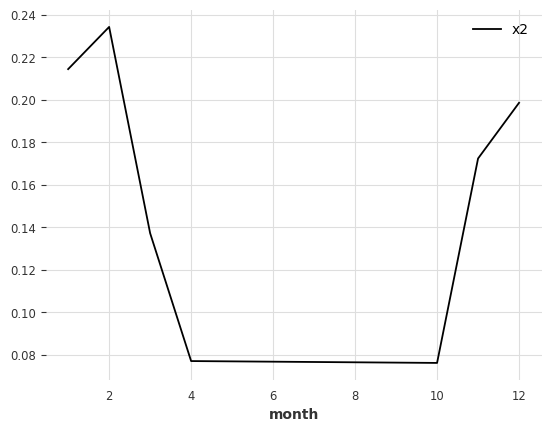

In [36]:
df.groupby('month')['x2'].mean().reset_index().plot(x='month', y='x2')

In [43]:
df = pd.read_csv('train_hourly.csv')


def augment_df(df, dropId = True):
    df = df.merge(devices, on="deviceId", how="left")

    df["timedate"] = pd.to_datetime(df["hour"], utc=True)

    # encode time features
    df["year"] = df["timedate"].dt.year
    df["month"] = df["timedate"].dt.month
    df["hour"] = df["timedate"].dt.hour

    #df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"]) / 12)

    df["hour_sin"] = np.sin(2 * np.pi * (df["hour"] + 5) / 24)
    #df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    #df["temp_diff"] = df["t1"] - (df["t2"]- 0.5)/ 4

    df.drop(columns=["timedate", "hour", "period"], inplace=True)

    if dropId:
        df.drop(columns=["deviceId", "year", "month"], inplace=True) 

    return df

train_df = augment_df(pd.read_csv('train_hourly.csv'))
valid_df = augment_df(pd.read_csv('valid_hourly.csv'), dropId=False)
test_df = augment_df(pd.read_csv('test_hourly.csv'), dropId=False)

In [29]:
train_df.head()

,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,...,x1,x2,t1_min,t1_max,x3,deviceType,latitude,longitude,month_sin,hour_sin
0,0.290000,0.05,0.0,0.372500,0.446667,0.438333,0.200000,0.499167,0.394167,0.210000,...,0.0,0.047606,0.29,0.29,8,19,50.0,18.3,-0.866025,0.965926
1,0.290000,0.05,0.0,0.418333,0.464167,0.452500,0.200000,0.514167,0.408333,0.210000,...,0.0,0.150090,0.29,0.29,8,19,50.0,18.3,-0.866025,1.000000
2,0.290000,0.05,0.0,0.447500,0.477500,0.450000,0.205833,0.530833,0.390000,0.210000,...,0.0,0.378862,0.29,0.29,8,19,50.0,18.3,-0.866025,0.965926
3,0.286667,0.05,0.0,0.392500,0.459167,0.452500,0.210000,0.506667,0.403333,0.210000,...,0.0,0.097856,0.28,0.29,8,19,50.0,18.3,-0.866025,0.866025
4,0.280000,0.05,0.0,0.445000,0.473333,0.456667,0.210000,0.521667,0.415000,0.208333,...,0.0,0.223482,0.28,0.28,8,19,50.0,18.3,-0.866025,0.707107


In [30]:
train_df.shape

(2905879, 23)

In [41]:
split_point = int(0.8 * train_df.shape[0])
train_test_df = train_df[:split_point]
train_valid_df = train_df[split_point:]

In [70]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

target = "x2"

X = train_df.drop(columns=[target])
y = train_df[target]

split_idx = int(len(train_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Model parameters
params = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "max_depth": 10,
    "eta": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# Train model
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1800,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=20,
)

# Predict
preds = model.predict(dtest)

# Evaluate
rmse = mean_absolute_error(y_test, preds)
print("MAE:", rmse)

[0]	train-mae:0.14082	test-mae:0.13263
[1]	train-mae:0.13687	test-mae:0.12893
[2]	train-mae:0.13304	test-mae:0.12536
[3]	train-mae:0.12950	test-mae:0.12208
[4]	train-mae:0.12590	test-mae:0.11873
[5]	train-mae:0.12287	test-mae:0.11593
[6]	train-mae:0.11995	test-mae:0.11333
[7]	train-mae:0.11715	test-mae:0.11081
[8]	train-mae:0.11396	test-mae:0.10782
[9]	train-mae:0.11086	test-mae:0.10495
[10]	train-mae:0.10786	test-mae:0.10220
[11]	train-mae:0.10498	test-mae:0.09958
[12]	train-mae:0.10236	test-mae:0.09724
[13]	train-mae:0.10008	test-mae:0.09516
[14]	train-mae:0.09745	test-mae:0.09277
[15]	train-mae:0.09493	test-mae:0.09050
[16]	train-mae:0.09270	test-mae:0.08849
[17]	train-mae:0.09072	test-mae:0.08681
[18]	train-mae:0.08839	test-mae:0.08473
[19]	train-mae:0.08629	test-mae:0.08292
[20]	train-mae:0.08450	test-mae:0.08131
[21]	train-mae:0.08238	test-mae:0.07950
[22]	train-mae:0.08071	test-mae:0.07814
[23]	train-mae:0.07871	test-mae:0.07642
[24]	train-mae:0.07692	test-mae:0.07487
[25]	train

In [71]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

target = "x2"

X = train_df.drop(columns=[target])
y = train_df[target]

X_train = X

y_train = y

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)

# Model parameters
params = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "max_depth": 10,
    "eta": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# Train model
model = xgb.train(
    params,
    dtrain,
    num_boost_round=320,
    evals=[(dtrain, "train")],
    early_stopping_rounds=20,
)

# Predict
#preds = model.predict(dtest)

# Evaluate
#rmse = mean_absolute_error(y_test, preds)
#print("MAE:", rmse)

[0]	train-mae:0.13894
[1]	train-mae:0.13506
[2]	train-mae:0.13128
[3]	train-mae:0.12780
[4]	train-mae:0.12426
[5]	train-mae:0.12124
[6]	train-mae:0.11836
[7]	train-mae:0.11562
[8]	train-mae:0.11247
[9]	train-mae:0.10943
[10]	train-mae:0.10648
[11]	train-mae:0.10365
[12]	train-mae:0.10108
[13]	train-mae:0.09882
[14]	train-mae:0.09624
[15]	train-mae:0.09376
[16]	train-mae:0.09158
[17]	train-mae:0.08964
[18]	train-mae:0.08735
[19]	train-mae:0.08530
[20]	train-mae:0.08355
[21]	train-mae:0.08147
[22]	train-mae:0.07984
[23]	train-mae:0.07788
[24]	train-mae:0.07614
[25]	train-mae:0.07430
[26]	train-mae:0.07256
[27]	train-mae:0.07117
[28]	train-mae:0.06953
[29]	train-mae:0.06794
[30]	train-mae:0.06671
[31]	train-mae:0.06521
[32]	train-mae:0.06379
[33]	train-mae:0.06240
[34]	train-mae:0.06113
[35]	train-mae:0.05987
[36]	train-mae:0.05863
[37]	train-mae:0.05764
[38]	train-mae:0.05656
[39]	train-mae:0.05543
[40]	train-mae:0.05440
[41]	train-mae:0.05341
[42]	train-mae:0.05256
[43]	train-mae:0.0516

In [72]:
target = "x2"

full_test = pd.concat([valid_df, test_df], ignore_index=True)
feature_cols = [c for c in full_test.columns if c not in ['x2', 'deviceId', 'year', 'month']]

X_submit = full_test[feature_cols]
dsubmit = xgb.DMatrix(X_submit)
full_test['prediction'] = np.clip(model.predict(dsubmit), 0, None)

submission = (
    full_test.groupby(['deviceId', 'year', 'month'])['prediction']
    .mean()
    .reset_index()
)

# 5. Format and Save
# Ensure the columns match the submission requirements exactly
submission = submission[['deviceId', 'year', 'month', 'prediction']]
pd.DataFrame.to_parquet(submission, 'submission.parquet')
submission.to_csv("submission.csv", index=False)

print(f"Submission file created with {len(submission)} rows.")
print(submission.head())

Submission file created with 3559 rows.
                                            deviceId  year  month  prediction
0  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      5    0.084065
1  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      6    0.020586
2  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      7    0.015421
3  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      8    0.021488
4  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      9    0.055669


In [25]:
pd.read_csv('submission.csv').head()

,deviceId,year,month,prediction
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,5,0.086681
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,6,0.019781
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,7,0.018379
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,8,0.023694
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,9,0.057270


In [10]:
submission.value_counts('deviceId')

deviceId
ffd5e815486d2b094a0ff197111e96c998e11fda1626f71f176af4b1c3296d4e    6
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe    6
005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30fe5a99d7a76b53f9fc9    6
01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2e1f6ac48b9de8ad5dd    6
01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfcc89f1f92902934f571    6
                                                                   ..
c5761e3bb51a4736bafd9ef9cba827f52b34291ae62760174293078803186264    3
71e933de062f206b3c75ab7e2f85d8cbcad40c0e2be9c9f6f041d73f0e8349e1    3
9836b6354391c6892c17b1d7e36230d122fb5f5c5b741044e00bbed4335a1596    3
25ed3d2359d3509aba1c90d746c800802f5dbd101683b4afba1b568711dbf61b    3
2b6cc01a05292397d20f7a64b2b399197d04057091b776522c198f7dd2bd60a3    3
Name: count, Length: 600, dtype: int64